In [4]:
#Aquino, Alexander M.
#Doctor of Engineering CpE
#BioInformatics

In [5]:
import os
from PIL import Image

DATASET_PATH = r"C:\Users\Acer\OneDrive - Bulacan State University\Desktop\PetImages"
removed_count = 0

print("Scanning dataset for corrupted files...")

# Scan both Cat and Dog subfolders
for category in ['Cat', 'Dog']:
    folder_path = os.path.join(DATASET_PATH, category)
    if os.path.exists(folder_path):
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            try:
                # Try to open and verify the image headers
                img = Image.open(file_path)
                img.verify()
            except Exception as e:
                # If it fails, close and delete the bad file
                print(f"Removed corrupted file: {filename}")
                os.remove(file_path)
                removed_count += 1

print(f"Scan complete. Removed {removed_count} corrupted files.")

Scanning dataset for corrupted files...
Scan complete. Removed 0 corrupted files.


In [6]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. EXACT DATASET PATH
DATASET_PATH = r"C:\Users\Acer\OneDrive - Bulacan State University\Desktop\PetImages"

# 2. DATA PREPROCESSING & GENERATORS (128x128 RGB, 20% Validation Split)
IMG_SIZE = 128
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255.0,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# 3. TUNED 4-LAYER 2D CNN ARCHITECTURE
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# 4. COMPILE MODEL
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. EARLY STOPPING CALLBACK
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# 6. EXECUTE TRAINING
history = model.fit(
    train_generator,
    epochs=35,
    validation_data=val_generator,
    callbacks=[early_stopping],
    verbose=1
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Epoch 1/35
625/625 [==============================] - 249s 397ms/step - loss: 0.6178 - accuracy: 0.6472 - val_loss: 0.5154 - val_accuracy: 0.7479
Epoch 2/35
625/625 [==============================] - 246s 394ms/step - loss: 0.5072 - accuracy: 0.7523 - val_loss: 0.4588 - val_accuracy: 0.7861
Epoch 3/35
625/625 [==============================] - 245s 392ms/step - loss: 0.4424 - accuracy: 0.7971 - val_loss: 0.4251 - val_accuracy: 0.8079
Epoch 4/35
625/625 [==============================] - 247s 395ms/step - loss: 0.3986 - accuracy: 0.8217 - val_loss: 0.4333 - val_accuracy: 0.7933
Epoch 5/35
625/625 [==============================] - 251s 402ms/step - loss: 0.3730 - accuracy: 0.8345 - val_loss: 0.3832 - val_accuracy: 0.8255
Epoch 6/35
625/625 [==============================] - 248s 398ms/step - loss: 0.3446 - accuracy: 0.8478 - val_loss: 0.3494 - val_accuracy: 0.8435
Epoch 7/35
625/625 [===================

In [15]:
# Save the complete model (architecture, weights, and optimizer state)
model.save('dogs_vs_cats_cnn.h5')
print("Model successfully saved as 'dogs_vs_cats_cnn.h5'")

Model successfully saved as 'dogs_vs_cats_cnn.h5'


In [16]:
import tensorflow as tf

# Load the saved model from disk
loaded_model = tf.keras.models.load_model('dogs_vs_cats_cnn.h5')

# Verify the model structure
loaded_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 14, 14, 128)     

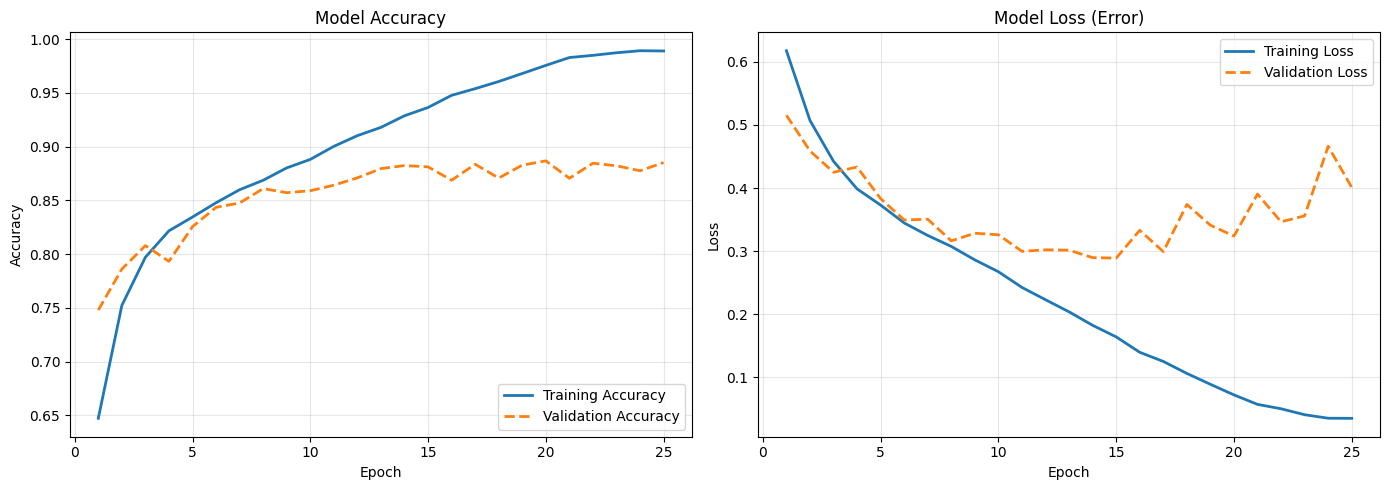

In [9]:
import matplotlib.pyplot as plt

# 1. Extract the metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Define the x-axis based on the actual number of epochs run
epochs_range = range(1, len(acc) + 1)

# 2. Set up the figure size
plt.figure(figsize=(14, 5))

# 3. Plot Accuracy (Training vs. Validation)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# 4. Plot Loss (Training vs. Validation)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
plt.title('Model Loss (Error)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Display the graphs
plt.tight_layout()
plt.show()

In [10]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Quick Final Accuracy Summary
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"=== FINAL MODEL SUMMARY ===")
print(f"Final Validation Accuracy: {val_acc * 100:.2f}%")
print(f"Final Validation Loss: {val_loss:.4f}\n")

# 2. Reset the generator so predictions line up perfectly with true labels
val_generator.reset()

# 3. Get the model's predictions on the validation set
print("Generating predictions for summary reports... (this may take a moment)")
predictions = model.predict(val_generator, verbose=1)

# Convert probability scores (0.0 to 1.0) into binary class labels (0 or 1)
# Typically: 0 = Cat, 1 = Dog
predicted_classes = np.where(predictions > 0.5, 1, 0)
true_classes = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# 4. Detailed Classification Report
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# 5. Confusion Matrix
print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(true_classes, predicted_classes)
print(f"{class_names[0]} (True)  | {cm[0][0]:<5} (Predicted {class_names[0]}) | {cm[0][1]:<5} (Predicted {class_names[1]})")
print(f"{class_names[1]} (True)  | {cm[1][0]:<5} (Predicted {class_names[0]}) | {cm[1][1]:<5} (Predicted {class_names[1]})")

=== FINAL MODEL SUMMARY ===
Final Validation Accuracy: 88.68%
Final Validation Loss: 0.3239

Generating predictions for summary reports... (this may take a moment)
157/157 [==============================] - 18s 115ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         Cat       0.90      0.87      0.88      2499
         Dog       0.87      0.90      0.89      2499

    accuracy                           0.89      4998
   macro avg       0.89      0.89      0.89      4998
weighted avg       0.89      0.89      0.89      4998


=== CONFUSION MATRIX ===
Cat (True)  | 2172  (Predicted Cat) | 327   (Predicted Dog)
Dog (True)  | 239   (Predicted Cat) | 2260  (Predicted Dog)


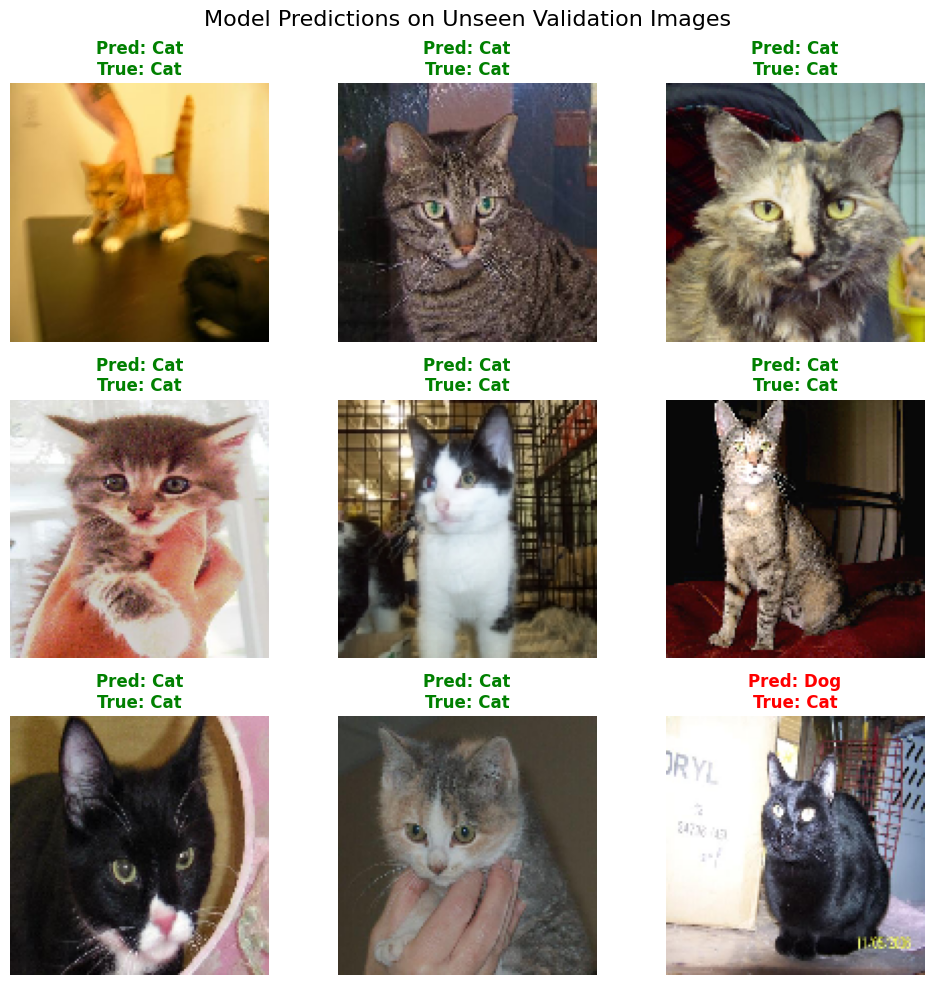

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Grab a single batch of images and their true labels from the validation set
val_generator.reset()
images, true_labels = next(val_generator)

# 2. Get the model's predictions just for this batch
batch_predictions = model.predict(images, verbose=0)
predicted_labels = np.where(batch_predictions > 0.5, 1, 0).flatten()

# 3. Get the class names (usually 0: 'Cat', 1: 'Dog')
class_indices = val_generator.class_indices
class_names = {v: k for k, v in class_indices.items()}

# 4. Set up a 3x3 grid to display 9 images
plt.figure(figsize=(10, 10))
plt.suptitle("Model Predictions on Unseen Validation Images", fontsize=16)

for i in range(9):
    plt.subplot(3, 3, i + 1)
    
    # Display the image
    plt.imshow(images[i])
    
    # Determine true and predicted labels
    true_class = class_names[int(true_labels[i])]
    pred_class = class_names[predicted_labels[i]]
    
    # Color the text green if correct, red if incorrect
    text_color = 'green' if true_class == pred_class else 'red'
    
    plt.title(f"Pred: {pred_class}\nTrue: {true_class}", color=text_color, fontweight='bold')
    plt.axis('off') # Hide the axis ticks for a cleaner look

plt.tight_layout()
plt.show()